In [2]:
import os

DATASET_PATH = "/content/drive/MyDrive/rawimgs"

classes = ["AluCan", "Glass", "PET", "HDPEM"]

In [3]:
for cls in classes:
    class_path = os.path.join(DATASET_PATH, cls)
    count = len(os.listdir(class_path))
    print(f"{cls}: {count} images")

AluCan: 1060 images
Glass: 1232 images
PET: 1508 images
HDPEM: 1028 images


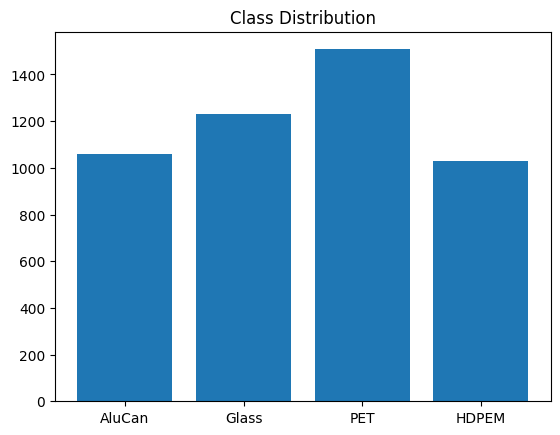

In [4]:
import matplotlib.pyplot as plt

counts = []

for cls in classes:
    path = os.path.join(DATASET_PATH, cls)
    counts.append(len(os.listdir(path)))

plt.bar(classes, counts)
plt.title("Class Distribution")
plt.show()

In [5]:
import os
import pandas as pd

dataset_path = "/content/drive/MyDrive/rawimgs"

classes = ["AluCan", "Glass", "PET", "HDPEM"]

data = []

for cls in classes:
    class_dir = os.path.join(dataset_path, cls)

    for img in os.listdir(class_dir):
        data.append([
            os.path.join(class_dir, img),
            cls
        ])

df = pd.DataFrame(data, columns=["filepath", "label"])

print(df.head())
print(df["label"].value_counts())

                                            filepath   label
0  /content/drive/MyDrive/rawimgs/AluCan/AluCan1,...  AluCan
1  /content/drive/MyDrive/rawimgs/AluCan/AluCan11...  AluCan
2  /content/drive/MyDrive/rawimgs/AluCan/AluCan10...  AluCan
3  /content/drive/MyDrive/rawimgs/AluCan/AluCan10...  AluCan
4  /content/drive/MyDrive/rawimgs/AluCan/AluCan1,...  AluCan
label
PET       1508
Glass     1232
AluCan    1060
HDPEM     1028
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 3379
Validation: 724
Test: 725


In [7]:
print("\nTrain")
print(train_df["label"].value_counts(normalize=True))

print("\nValidation")
print(val_df["label"].value_counts(normalize=True))

print("\nTest")
print(test_df["label"].value_counts(normalize=True))



Train
label
PET       0.312223
Glass     0.255105
AluCan    0.219592
HDPEM     0.213081
Name: proportion, dtype: float64

Validation
label
PET       0.312155
Glass     0.255525
AluCan    0.219613
HDPEM     0.212707
Name: proportion, dtype: float64

Test
label
PET       0.313103
Glass     0.255172
AluCan    0.219310
HDPEM     0.212414
Name: proportion, dtype: float64


In [8]:
import shutil

output_dir = "/content/split_dataset"

for split_name in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(
            os.path.join(output_dir, split_name, cls),
            exist_ok=True
        )

In [9]:
def copy_files(dataframe, split_name):

    for _, row in dataframe.iterrows():

        src = row["filepath"]

        dst = os.path.join(
            output_dir,
            split_name,
            row["label"],
            os.path.basename(src)
        )

        shutil.copy2(src, dst)

copy_files(train_df, "train")
copy_files(val_df, "val")
copy_files(test_df, "test")

In [10]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [11]:
train_dir = "/content/split_dataset/train"
val_dir = "/content/split_dataset/val"
test_dir = "/content/split_dataset/test"

IMG_SIZE = (224,224)
BATCH_SIZE = 32

In [12]:
train_datagen = ImageDataGenerator(
    rescale=1./255,

    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,

    zoom_range=0.2,

    brightness_range=[0.8,1.2],

    horizontal_flip=True,

    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [13]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 3373 images belonging to 4 classes.
Found 723 images belonging to 4 classes.
Found 724 images belonging to 4 classes.


In [14]:
class_names = list(train_generator.class_indices.keys())

print(class_names)

['AluCan', 'Glass', 'HDPEM', 'PET']


In [15]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [17]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)

x = Dropout(0.4)(x)

predictions = Dense(
    4,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=predictions
)

In [18]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    save_best_only=True,
    monitor='val_accuracy'
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/25
106/106 ━━━━━━━━━━━━━━━━━━━━ 260s 2s/step - accuracy: 0.7622 - loss: 0.6175 - val_accuracy: 0.8976 - val_loss: 0.2611 - learning_rate: 0.0010
Epoch 2/25
106/106 ━━━━━━━━━━━━━━━━━━━━ 249s 2s/step - accuracy: 0.8841 - loss: 0.3050 - val_accuracy: 0.9378 - val_loss: 0.1726 - learning_rate: 0.0010
Epoch 3/25
106/106 ━━━━━━━━━━━━━━━━━━━━ 260s 2s/step - accuracy: 0.9066 - loss: 0.2611 - val_accuracy: 0.9433 - val_loss: 0.1663 - learning_rate: 0.0010
Epoch 4/25
106/106 ━━━━━━━━━━━━━━━━━━━━ 256s 2s/step - accuracy: 0.9170 - loss: 0.2216 - val_accuracy: 0.9516 - val_loss: 0.1483 - learning_rate: 0.0010
Epoch 5/25
106/106 ━━━━━━━━━━━━━━━━━━━━ 266s 2s/step - accuracy: 0.9286 - loss: 0.1838 - val_accuracy: 0.9571 - val_loss: 0.1238 - learning_rate: 0.0010
Epoch 6/25
106/106 ━━━━━━━━━━━━━━━━━━━━ 251s 2s/step - accuracy: 0.9303 - loss: 0.1835 - val_accuracy: 0.9585 - val_loss: 0.1039 - learning_rate: 0.0010
Epoch 7/25
106/106 ━━━━━━━━━━━━━━━━━━━━ 251s 2s/step - accuracy: 0.9463 - loss: 0.

In [20]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/25
106/106 ━━━━━━━━━━━━━━━━━━━━ 110s 852ms/step - accuracy: 0.7688 - loss: 0.6184 - val_accuracy: 0.8907 - val_loss: 0.2805 - learning_rate: 0.0010
Epoch 2/25
106/106 ━━━━━━━━━━━━━━━━━━━━ 63s 591ms/step - accuracy: 0.8844 - loss: 0.3192 - val_accuracy: 0.9281 - val_loss: 0.2079 - learning_rate: 0.0010
Epoch 3/25
106/106 ━━━━━━━━━━━━━━━━━━━━ 61s 578ms/step - accuracy: 0.9152 - loss: 0.2351 - val_accuracy: 0.9281 - val_loss: 0.1831 - learning_rate: 0.0010
Epoch 4/25
106/106 ━━━━━━━━━━━━━━━━━━━━ 63s 591ms/step - accuracy: 0.9226 - loss: 0.2025 - val_accuracy: 0.9405 - val_loss: 0.1513 - learning_rate: 0.0010
Epoch 5/25
106/106 ━━━━━━━━━━━━━━━━━━━━ 61s 577ms/step - accuracy: 0.9330 - loss: 0.1752 - val_accuracy: 0.9557 - val_loss: 0.1337 - learning_rate: 0.0010
Epoch 6/25
106/106 ━━━━━━━━━━━━━━━━━━━━ 61s 577ms/step - accuracy: 0.9437 - loss: 0.1571 - val_accuracy: 0.9723 - val_loss: 0.0964 - learning_rate: 0.0010
Epoch 7/25
106/106 ━━━━━━━━━━━━━━━━━━━━ 62s 587ms/step - accuracy: 0.

In [21]:
model.save(
    "/content/drive/MyDrive/waste_classifier.keras"
)

In [22]:
test_loss, test_acc = model.evaluate(
    test_generator
)

print("Test Accuracy:", test_acc)

23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 693ms/step - accuracy: 0.9655 - loss: 0.0924
Test Accuracy: 0.9654695987701416


In [23]:
predictions = model.predict(
    test_generator
)

y_pred = np.argmax(
    predictions,
    axis=1
)

y_true = test_generator.classes

23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 339ms/step


In [24]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9654696132596685
Precision: 0.9663115927061281
Recall   : 0.9654696132596685
F1 Score : 0.9655704396697635


In [25]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      AluCan       0.98      0.97      0.97       159
       Glass       0.93      0.98      0.95       184
       HDPEM       0.96      0.97      0.96       154
         PET       0.99      0.95      0.97       227

    accuracy                           0.97       724
   macro avg       0.96      0.97      0.97       724
weighted avg       0.97      0.97      0.97       724



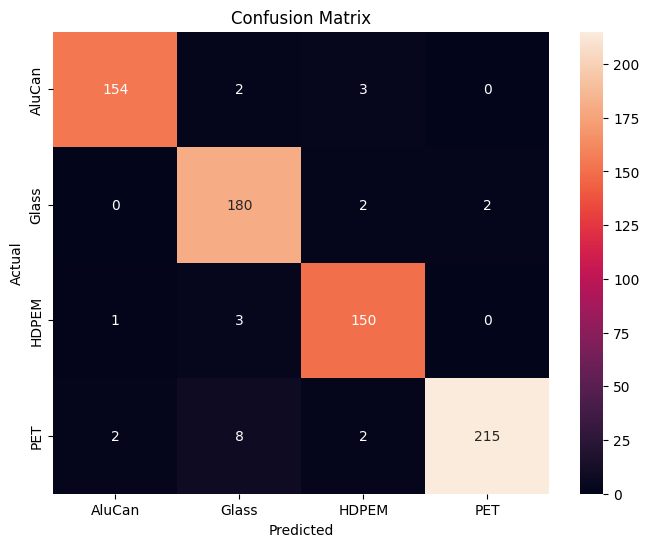

In [26]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

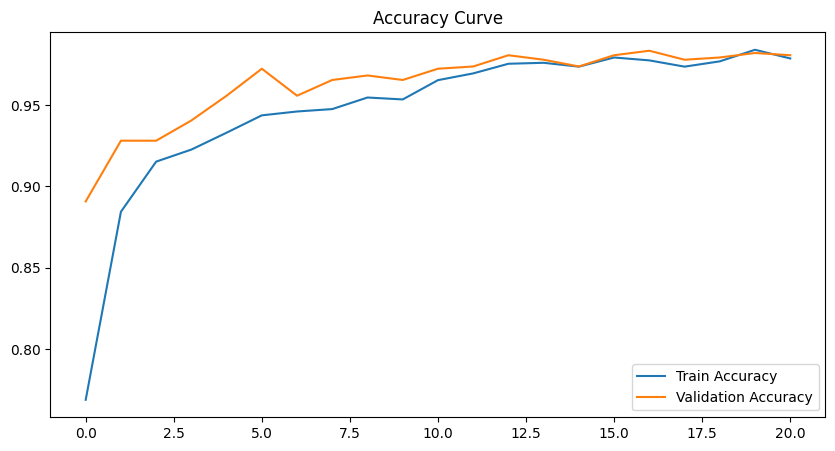

In [27]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.legend()

plt.title("Accuracy Curve")

plt.show()

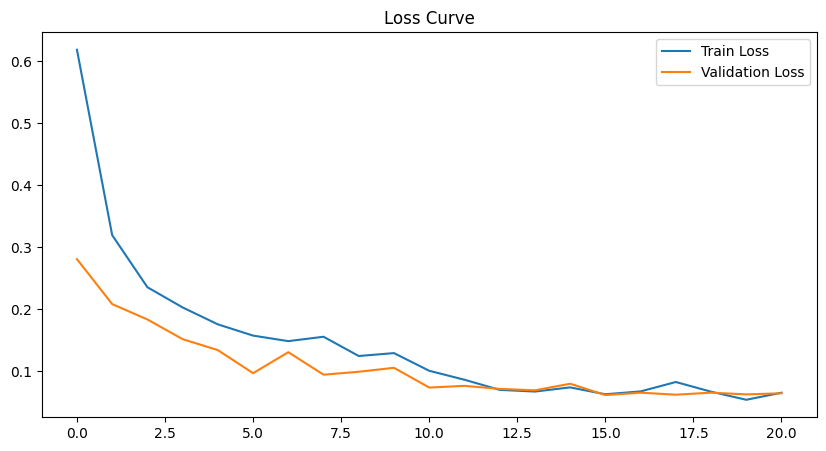

In [28]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.legend()

plt.title("Loss Curve")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


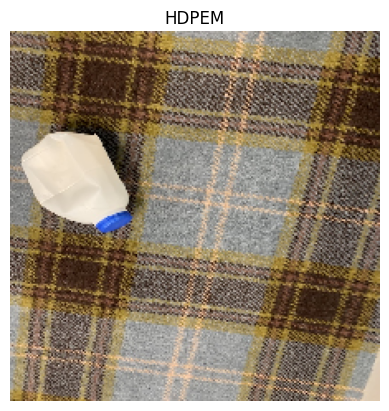

In [29]:
import random
from tensorflow.keras.preprocessing import image

sample_file = random.choice(
    test_generator.filepaths
)

img = image.load_img(
    sample_file,
    target_size=(224,224)
)

img_array = image.img_to_array(img)/255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

pred = model.predict(img_array)

pred_class = class_names[
    np.argmax(pred)
]

plt.imshow(img)
plt.title(pred_class)
plt.axis('off')
plt.show()

In [46]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):

    # Create a model that maps the input image to the activations of the last convolutional layer
    # and the model's final output (predictions)
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [base_model.get_layer(last_conv_layer_name).output, model.output] # Corrected line
    )

    with tf.GradientTape() as tape:
        # Compute the activations of the last conv layer and the predictions
        conv_outputs, predictions = grad_model(img_array)

        # If no specific prediction index is provided, use the top predicted class
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        # Get the class channel for the predicted class
        class_channel = predictions[:, pred_index]

    # Compute the gradients of the top predicted class with respect to the last conv layer feature map
    grads = tape.gradient(class_channel, conv_outputs)

    # Pool the gradients over all the spatial dimensions (height and width)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Take the output of the last convolutional layer
    conv_outputs = conv_outputs[0]

    # Multiply each channel in the feature map by the importance of the channel (pooled_grads)
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize the heatmap to be in the range [0, 1]
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [47]:
last_conv_layer_name = None

# Iterate through base_model layers in reverse to find the last convolutional layer
# This approach should be generally robust for functional API models
for layer in reversed(base_model.layers):
    # Check if the layer is a convolutional type (Conv2D or DepthwiseConv2D)
    # and ensures it outputs a 4D tensor (batch, height, width, channels)
    if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.DepthwiseConv2D)) and \
       hasattr(layer, 'output_shape') and layer.output_shape is not None and len(layer.output_shape) == 4:
        last_conv_layer_name = layer.name
        break

# If the generic loop didn't find it (which is unusual for MobileNetV2),
# try specific known names as fallbacks.
if last_conv_layer_name is None:
    try:
        # Common name for the last projection convolution layer in MobileNetV2
        last_conv_layer_name = base_model.get_layer('block_16_project_conv').name
    except ValueError:
        try:
            # Another common name for the final feature map producing convolution layer in MobileNetV2
            last_conv_layer_name = base_model.get_layer('Conv_1').name
        except ValueError:
            print("Warning: Could not find common MobileNetV2 convolutional layer names like 'block_16_project_conv' or 'Conv_1'.")
            pass # last_conv_layer_name remains None if both fail


if last_conv_layer_name:
    print("Last Conv Layer:", last_conv_layer_name)
else:
    print("Critical Error: Failed to identify a suitable last convolutional layer for Grad-CAM.")

Last Conv Layer: Conv_1


In [48]:
import random
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import cv2

sample_file = random.choice(test_generator.filepaths)

img = image.load_img(sample_file, target_size=(224,224))

img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Prediction
pred = model.predict(img_array)
pred_class = class_names[np.argmax(pred)]

# 🔥 Grad-CAM heatmap
heatmap = make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


In [49]:
img = cv2.imread(sample_file)
img = cv2.resize(img, (224,224))

heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

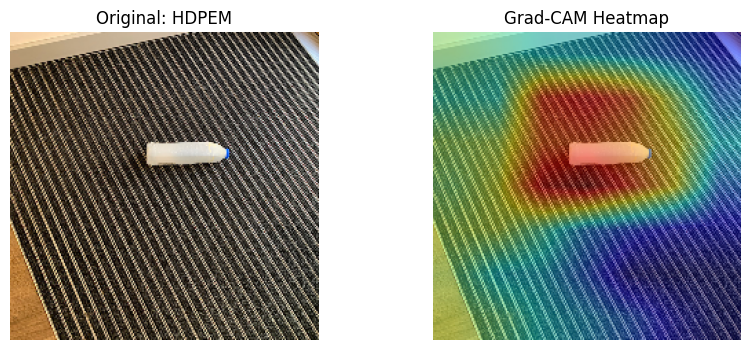

In [50]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original: " + pred_class)
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.show()